In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import random
from collections import defaultdict
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import seaborn as sns
import scipy.stats as stats
from tabulate import tabulate
from scipy.stats import mode

In [2]:
premier_data = pd.read_excel('Premier_Teams_Ranking_Enhanced.xlsx')

In [3]:
print(premier_data.head())

      Season  Rank        Team Name  Games Played  Wins  Draws  Loss  \
0  2023-2024     1  Manchester City            38    28      7     3   
1  2023-2024     2          Arsenal            38    28      5     5   
2  2023-2024     3        Liverpool            38    24     10     4   
3  2023-2024     4      Aston Villa            38    20      8    10   
4  2023-2024     5        Tottenham            38    20      6    12   

   Goals For  Goals Against  Goal Difference  Points  Points Per Game  \
0         96             34               62      91             2.39   
1         91             29               62      89             2.34   
2         86             41               45      82             2.16   
3         76             61               15      68             1.79   
4         74             61               13      66             1.74   

   Expected Goals  Expected Goals Allowed  Expected Goals Difference  \
0            80.5                    35.6               

In [4]:
# Group the historical_records by Season and count the unique Team values to get the number of teams in each season.
teams_per_season = premier_data.groupby('Season')['Team Name'].nunique()

# Group the historical_records by Season and sum the Wins and Losses for each team to get the total number of games played by each team in each season.
games_played_per_team_per_season = (premier_data.groupby('Season')['Games Played'].sum()/teams_per_season)

# Create a new DataFrame with the number of teams and games played per season.
season_summary = pd.DataFrame({
    'Season': teams_per_season.index,
    'Number of Teams': teams_per_season.values,
    'Games Played per Team': games_played_per_team_per_season.values
})

print(season_summary)

       Season  Number of Teams  Games Played per Team
0   1946-1947               22                   42.0
1   1947-1948               22                   42.0
2   1948-1949               22                   42.0
3   1949-1950               22                   42.0
4   1950-1951               22                   42.0
..        ...              ...                    ...
73  2019-2020               20                   38.0
74  2020-2021               20                   38.0
75  2021-2022               20                   38.0
76  2022-2023               20                   38.0
77  2023-2024               20                   38.0

[78 rows x 3 columns]


In [5]:
season_summary = season_summary[season_summary['Season'] >= '1981-1982']
print(season_summary)

       Season  Number of Teams  Games Played per Team
35  1981-1982               22                   42.0
36  1982-1983               22                   42.0
37  1983-1984               22                   42.0
38  1984-1985               22                   42.0
39  1985-1986               22                   42.0
40  1986-1987               22                   42.0
41  1987-1988               21                   40.0
42  1988-1989               20                   38.0
43  1989-1990               20                   38.0
44  1990-1991               20                   38.0
45  1991-1992               22                   42.0
46  1992-1993               22                   42.0
47  1993-1994               22                   42.0
48  1994-1995               22                   42.0
49  1995-1996               20                   38.0
50  1996-1997               20                   38.0
51  1997-1998               20                   38.0
52  1998-1999               

To speed up the simulation, we run the 100 simulations once for each group of seasons that share the same number of teams and number of games played. For premier league, for seasons after 1980, there are only 3 season groups, so the 100 simulation of each combination of s and c only execute 3 times, instead of running that many simulations for each season, which is 40 plus times of running it. So here, I got the list of seasons and their corresponding number of teams and games played and grouped them by this two parameters.

In [6]:
# Data for seasons
seasons_data = [
    {"Season": "1981-1982", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1982-1983", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1983-1984", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1984-1985", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1985-1986", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1986-1987", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1987-1988", "Number of Teams": 21, "Games Played per Team": 40},
    {"Season": "1988-1989", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1989-1990", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1990-1991", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1991-1992", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1992-1993", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1993-1994", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1994-1995", "Number of Teams": 22, "Games Played per Team": 42},
    {"Season": "1995-1996", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1996-1997", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1997-1998", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1998-1999", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "1999-2000", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2000-2001", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2001-2002", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2002-2003", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2003-2004", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2004-2005", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2005-2006", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2006-2007", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2007-2008", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2008-2009", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2009-2010", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2010-2011", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2011-2012", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2012-2013", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2013-2014", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2014-2015", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2015-2016", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2016-2017", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2017-2018", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2018-2019", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2019-2020", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2020-2021", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2021-2022", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2022-2023", "Number of Teams": 20, "Games Played per Team": 38},
    {"Season": "2023-2024", "Number of Teams": 20, "Games Played per Team": 38},
]

grouped_seasons = defaultdict(list)

for season in seasons_data:
    key = (season["Number of Teams"], season["Games Played per Team"])
    grouped_seasons[key].append(season["Season"])

# Print grouped seasons
for key, seasons in grouped_seasons.items():
    print(f"Group: {key[0]} Teams, {key[1]} Games")
    for season in seasons:
        print(f"  - {season}")

Group: 22 Teams, 42 Games
  - 1981-1982
  - 1982-1983
  - 1983-1984
  - 1984-1985
  - 1985-1986
  - 1986-1987
  - 1991-1992
  - 1992-1993
  - 1993-1994
  - 1994-1995
Group: 21 Teams, 40 Games
  - 1987-1988
Group: 20 Teams, 38 Games
  - 1988-1989
  - 1989-1990
  - 1990-1991
  - 1995-1996
  - 1996-1997
  - 1997-1998
  - 1998-1999
  - 1999-2000
  - 2000-2001
  - 2001-2002
  - 2002-2003
  - 2003-2004
  - 2004-2005
  - 2005-2006
  - 2006-2007
  - 2007-2008
  - 2008-2009
  - 2009-2010
  - 2010-2011
  - 2011-2012
  - 2012-2013
  - 2013-2014
  - 2014-2015
  - 2015-2016
  - 2016-2017
  - 2017-2018
  - 2018-2019
  - 2019-2020
  - 2020-2021
  - 2021-2022
  - 2022-2023
  - 2023-2024


# Initial Phase - Find the Best c with b = 1

Since Premier League has ties, we introduced the ties frequency parameter b to have a better fit under this scenerio. And the first step I took is pretending it does not have ties and simulate the league to first get an universal c.

In [7]:
# Define the functions for the simulation
def generate_skills(t, s, mean=50, lower_bound=0, upper_bound=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
    skills = np.random.normal(mean, s, t)
    skills = np.clip(skills, lower_bound, upper_bound)
    return skills.tolist()

def simulate_match(s1, s2, c, b=1):
    p1 = (b * (c ** s1)) / (b * (c ** s1) + c ** s2)
    return np.random.rand() < p1

def create_schedule(t, m):
    teams = list(range(t))
    matches = []
    match_counts = {team: 0 for team in teams}
    while len(matches) < t * m // 2:
        for i in range(t):
            for j in range(i + 1, t):
                if match_counts[i] < m and match_counts[j] < m:
                    matches.append((i, j))
                    match_counts[i] += 1
                    match_counts[j] += 1
                    if len(matches) == t * m // 2:
                        break
            if len(matches) == t * m // 2:
                break
    return matches

def simulate_league(t, m, s, c, schedule, seed=None):
    skills = generate_skills(t, s, seed=seed)
    results = {team: {'wins': 0, 'losses': 0} for team in range(t)}
    for team1, team2 in schedule:
        if simulate_match(skills[team1], skills[team2], c):
            results[team1]['wins'] += 1
            results[team2]['losses'] += 1
        else:
            results[team2]['wins'] += 1
            results[team1]['losses'] += 1
    return results

def explore_s_c_parallel(t, m, s_range, c_range, schedule, iterations=100, seed=None):
    def run_simulation(s, c):
        ranked_wins_lists = []
        for _ in range(iterations):
            results = simulate_league(t, m, s, c, schedule, seed=seed)
            simulated_wins = [results[team]['wins'] for team in results]
            simulated_wins.sort(reverse=True)
            ranked_wins_lists.append(simulated_wins)
        return ranked_wins_lists, (s, c)

    results = Parallel(n_jobs=-1)(delayed(run_simulation)(s, c) for s in s_range for c in c_range)
    return results

def calculate_mse(simulated_wins, real_wins):
    mse = np.mean((np.array(simulated_wins) - np.array(real_wins)) ** 2)
    return mse

def compare_simulations_with_real(simulation_results, real_wins):
    mse_results = {}
    for ranked_wins_lists, (s, c) in simulation_results:
        mse_lists = {season: [] for season in seasons}
        for simulated_wins in ranked_wins_lists:
            for season in seasons:
                mse = calculate_mse(simulated_wins, real_wins[season])
                mse_lists[season].append(mse)
        mse_results[(s, c)] = mse_lists
    return mse_results

def most_frequent_mse(mse_list):
    mse_counter = Counter(mse_list)
    most_common_mse, _ = mse_counter.most_common(1)[0]
    return most_common_mse

def plot_ranked_wins(real_data, simulated_data, season):
    real_ranked_wins = sorted(real_data, reverse=True)
    simulated_ranked_wins = sorted(simulated_data, reverse=True)

    plt.figure(figsize=(10, 6))
    plt.plot(real_ranked_wins, label='Real Ranked Wins', marker='o')
    plt.plot(simulated_ranked_wins, label='Simulated Ranked Wins', marker='x')
    plt.title(f'Premier {season} Season - Real vs Simulated Ranked Wins')
    plt.xlabel('Team Rank')
    plt.ylabel('Number of Wins')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_mse_distribution(mse_list, s, c, season):
    plt.hist(mse_list, bins=40, edgecolor='k', alpha=0.7)
    plt.title(f'Distribution of MSE for s={s}, c={c}, Season={season}')
    plt.xlabel('MSE')
    plt.ylabel('Frequency')
    plt.show()

# Define the grouped seasons
grouped_seasons = {
    (22, 42): ['1981-1982', '1982-1983', '1983-1984', '1984-1985', '1985-1986', '1986-1987', '1991-1992', '1992-1993', '1993-1994', '1994-1995'],
    (21, 40): ['1987-1988'],
    (20, 38): ['1988-1989', '1989-1990', '1990-1991', '1995-1996', '1996-1997','1997-1998','1998-1999', '1999-2000','2000-2001',
               '2001-2002', '2002-2003', '2003-2004', '2004-2005','2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011',
               '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023','2023-2024']
}

# Initialize empty DataFrames to store results
all_mse_df = pd.DataFrame(columns=['s', 'c', 'Season', 'Most Frequent MSE'])
all_smallest_mse_df = pd.DataFrame(columns=['Season', 'MSE', 's', 'c'])

# Initialize an empty list to store the data for the DataFrame
mse_data = []

# Process each group
for (num_teams, num_games), seasons in grouped_seasons.items():
    print(f"Processing group: {num_teams} Teams, {num_games} Games")

    # Filter the data for the specified seasons
    filtered_data = premier_data[premier_data['Season'].isin(seasons)]

    # Get the ranked list of wins for each season
    real_wins = {}
    for season in seasons:
        season_data = filtered_data[filtered_data['Season'] == season]
        wins = season_data['Wins'].tolist()
        wins.sort(reverse=True)
        real_wins[season] = wins

    # Set the number of teams and matches
    t = num_teams
    m = num_games
    s_range = np.linspace(0, 10, 50)
    c_range = np.linspace(0.1, 10, 50)
    schedule = create_schedule(t, m)  # Create the schedule

    # Run the simulation
    simulation_results = explore_s_c_parallel(t, m, s_range, c_range, schedule, iterations=100, seed=None)

    # Compare simulation results with real data
    mse_results = compare_simulations_with_real(simulation_results, real_wins)


    # Get the most frequent MSE for each combination of s and c
    most_frequent_mses = {}
    for (s, c), mse_lists in mse_results.items():
        for season in seasons:
            most_frequent_mses[(s, c, season)] = most_frequent_mse(mse_lists[season])

    # Collect the data for the DataFrame
    for (s, c), mse_lists in mse_results.items():
        for season in seasons:
            most_frequent_mse_value = most_frequent_mses[(s, c, season)]
            mse_data.append({'s': s, 'c': c, 'Season': season, 'Most Frequent MSE': most_frequent_mse_value})

    # Create a DataFrame from the collected data
    mse_df = pd.DataFrame(mse_data)

Processing group: 22 Teams, 42 Games
Processing group: 21 Teams, 40 Games
Processing group: 20 Teams, 38 Games


In [8]:
print(mse_df)

           s     c     Season  Most Frequent MSE
0        0.0   0.1  1981-1982          36.136364
1        0.0   0.1  1982-1983          27.227273
2        0.0   0.1  1983-1984          30.545455
3        0.0   0.1  1984-1985          28.045455
4        0.0   0.1  1985-1986          33.545455
...      ...   ...        ...                ...
107495  10.0  10.0  2019-2020          61.500000
107496  10.0  10.0  2020-2021          54.750000
107497  10.0  10.0  2021-2022          50.300000
107498  10.0  10.0  2022-2023          52.650000
107499  10.0  10.0  2023-2024          44.700000

[107500 rows x 4 columns]


In [9]:
# group the data within df_s_c_season_mse based on c
# get the mean mse of each c group
# find the smallest mean mse, and it's corresponding c

# Group the data by c
grouped_data = mse_df.groupby('c')

# Calculate the mean of the mse for each group
mean_mse = grouped_data['Most Frequent MSE'].mean()

# Find the smallest mean mse and its corresponding c
smallest_mse = mean_mse.min()
best_c = mean_mse.idxmin()

# Print the results
print(f"Smallest mean MSE: {smallest_mse}")
print(f"Corresponding c: {best_c}")

Smallest mean MSE: 31.945967582804794
Corresponding c: 0.9081632653061225


# Secondary Phase - Find the Best b using the Optimal c

Taking the optimal c we got from the previous step, and set the previous varing c to be constant at the optimal value, and make b be varying. And we are also trying to find a universal b here to represent the ties frequency of the Premier League.

In [10]:
# Filter the data for seasons after the 1981 season
filtered_data = premier_data[premier_data['Season'].apply(lambda x: int(x.split('-')[0]) > 1981)]

# Get the wins, losses, and draws for each team and season
actual_results_with_ties = {}
for season in filtered_data['Season'].unique():
    season_data = filtered_data[filtered_data['Season'] == season]
    results = {}
    for _, row in season_data.iterrows():
        team = row['Team Name']
        if team not in results:
            results[team] = {'wins': 0, 'losses': 0, 'ties': 0}
        results[team]['wins'] = row['Wins']
        results[team]['ties'] = row['Draws']
        results[team]['Loss'] = row['Loss']
    actual_results_with_ties[season] = results

In [11]:
def simulate_match_with_ties(s1, s2, b):
    p1 = (b * (best_c ** s1)) / (b * (best_c ** s1) + best_c ** s2)
    p2 = (b * (best_c ** s2)) / (best_c ** s1 + b * (best_c ** s2))
    tie_prob = 1 - (p1 + p2)

    outcome = np.random.rand()
    if outcome < p1:
        return 1  # Team 1 wins
    elif outcome < p1 + tie_prob:
        return 0  # Tie
    else:
        return -1  # Team 2 wins

# Function to simulate a league with ties
def simulate_league_with_ties(t, m, s, b, schedule, seed=None):
    skills = generate_skills(t, s, seed=seed)
    results = {team: {'wins': 0, 'losses': 0, 'ties': 0, 'points': 0} for team in range(t)}

    for team1, team2 in schedule:
        outcome = simulate_match_with_ties(skills[team1], skills[team2], b)
        if outcome == 1:
            results[team1]['wins'] += 1
            results[team1]['points'] += 3
            results[team2]['losses'] += 1
        elif outcome == -1:
            results[team2]['wins'] += 1
            results[team2]['points'] += 3
            results[team1]['losses'] += 1
        else:
            results[team1]['ties'] += 1
            results[team2]['ties'] += 1
            results[team1]['points'] += 1
            results[team2]['points'] += 1

    return results

# Function to calculate MSE between the number of ties
def calculate_ties_mse(simulated_ties, real_ties):
    return np.mean((np.array(simulated_ties) - np.array(real_ties)) ** 2)

###
# Function to get ranked list of ties and wins based on points
def get_ranked_ties_and_wins(results):
    sorted_teams = sorted(results.items(), key=lambda x: x[1]['points'], reverse=True)
    ranked_ties = [results[team]['ties'] for team, _ in sorted_teams]
    ranked_wins = [results[team]['wins'] for team, _ in sorted_teams]
    return ranked_ties, ranked_wins

# Function to compare simulated results with real data for ties and wins
def compare_simulations_with_real(simulation_results, real_ties, real_wins):
    mse_results = {}
    for ranked_lists, (s, b) in simulation_results:
        mse_ties_lists = {season: [] for season in real_ties.keys()}
        mse_wins_lists = {season: [] for season in real_wins.keys()}
        for ranked_ties, ranked_wins in ranked_lists:
            for season in real_ties.keys():
                mse_ties = calculate_mse(ranked_ties, real_ties[season])
                mse_wins = calculate_mse(ranked_wins, real_wins[season])
                mse_ties_lists[season].append(mse_ties)
                mse_wins_lists[season].append(mse_wins)
        mse_results[(s, b)] = (mse_ties_lists, mse_wins_lists)
    return mse_results

# Function to explore s and b values in parallel
def explore_sb_parallel(t, m, s_range, b_range, schedule, iterations=100, seed=None):
    def run_simulation(s, b):
        ranked_lists = []
        for _ in range(iterations):
            results = simulate_league_with_ties(t, m, s, b, schedule, seed=seed)
            ranked_ties, ranked_wins = get_ranked_ties_and_wins(results)
            ranked_lists.append((ranked_ties, ranked_wins))
        return ranked_lists, (s, b)

    results = Parallel(n_jobs=-1)(delayed(run_simulation)(s, b) for s in s_range for b in b_range)
    return results
###


For this one, I try to let the program to get the mse based on both ranked wins list and ranked ties list to see which one gives back parameters that can produce a better fit.

In [12]:
# Main processing loop for each group of seasons
all_mse_data = []
for (num_teams, num_games), seasons in grouped_seasons.items():
    print(f"Processing group: {num_teams} Teams, {num_games} Games")

    # Filter the data for the specified seasons
    filtered_data = premier_data[premier_data['Season'].isin(seasons)]

    # Get the ranked list of ties and wins for each season
    real_ties = {}
    real_wins = {}
    for season in seasons:
        season_data = filtered_data[filtered_data['Season'] == season]
        season_data['Points'] = season_data['Wins'] * 3 + season_data['Draws']
        sorted_teams = season_data.sort_values(by='Points', ascending=False)
        ties = sorted_teams['Draws'].tolist()
        wins = sorted_teams['Wins'].tolist()
        real_ties[season] = ties
        real_wins[season] = wins

    # Set the number of teams and matches
    t = num_teams
    m = num_games
    s_range = np.linspace(0, 10, 50)
    b_range = np.linspace(0, 1, 50)
    schedule = create_schedule(t, m)  # Create the schedule

    # Run the simulation to find the best s and b
    simulation_results = explore_sb_parallel(t, m, s_range, b_range, schedule, iterations=100, seed=None)

    # Compare simulation results with real data
    mse_results = compare_simulations_with_real(simulation_results, real_ties, real_wins)

    # Get the most frequent MSE for each combination of s and b
    most_frequent_mses = {}
    for (s, b), (mse_ties_lists, mse_wins_lists) in mse_results.items():
        for season in seasons:
            most_frequent_mses[(s, b, season, 'ties')] = most_frequent_mse(mse_ties_lists[season])
            most_frequent_mses[(s, b, season, 'wins')] = most_frequent_mse(mse_wins_lists[season])

    # Collect the data for the DataFrame
    mse_data = []
    for (s, b), (mse_ties_lists, mse_wins_lists) in mse_results.items():
        for season in seasons:
            most_frequent_mse_ties = most_frequent_mses[(s, b, season, 'ties')]
            most_frequent_mse_wins = most_frequent_mses[(s, b, season, 'wins')]
            mse_data.append({'s': s, 'b': b, 'Season': season, 'Most Frequent MSE Ties': most_frequent_mse_ties, 'Most Frequent MSE Wins': most_frequent_mse_wins})

    all_mse_data.extend(mse_data)  # Accumulate data across iterations

# Create a DataFrame from the collected data
mse_df = pd.DataFrame(all_mse_data)

Processing group: 22 Teams, 42 Games


<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_data['Points'] = season_data['Wins'] * 3 + season_data['Draws']
<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_data['Points'] = season_data['Wins'] * 3 + season_data['Draws']
<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

Processing group: 21 Teams, 40 Games
Processing group: 20 Teams, 38 Games


<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_data['Points'] = season_data['Wins'] * 3 + season_data['Draws']
<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_data['Points'] = season_data['Wins'] * 3 + season_data['Draws']
<ipython-input-12-bbb74d90b98f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [13]:
print(mse_df)

           s    b     Season  Most Frequent MSE Ties  Most Frequent MSE Wins
0        0.0  0.0  1981-1982              968.000000              266.136364
1        0.0  0.0  1982-1983             1026.545455              270.227273
2        0.0  0.0  1983-1984              982.818182              261.636364
3        0.0  0.0  1984-1985             1047.454545              285.590909
4        0.0  0.0  1985-1986             1028.818182              293.454545
...      ...  ...        ...                     ...                     ...
107495  10.0  1.0  2019-2020               94.800000               31.200000
107496  10.0  1.0  2020-2021               76.200000               25.050000
107497  10.0  1.0  2021-2022               89.300000               26.500000
107498  10.0  1.0  2022-2023               83.200000               27.550000
107499  10.0  1.0  2023-2024               70.100000               21.500000

[107500 rows x 5 columns]


In [14]:
# group the data within df_s_c_season_mse based on b
# get the mean mse of each b group
# find the smallest mean mse, and it's corresponding b

# Group the data by c
grouped_data = mse_df.groupby('b')

# Calculate the mean of the mse for each group
mean_mse_ties = grouped_data['Most Frequent MSE Ties'].mean()
mean_mse_wins = grouped_data['Most Frequent MSE Wins'].mean()

# Find the smallest mean mse and its corresponding b
smallest_mse_ties = mean_mse_ties.min()
best_b_ties = mean_mse_ties.idxmin()
smallest_mse_wins = mean_mse_wins.min()
best_b_wins = mean_mse_wins.idxmin()

# Print the results
print(f"Smallest mean MSE Ties: {smallest_mse_ties}")
print(f"Corresponding b: {best_b_ties}")

# Print the results
print(f"Smallest mean MSE Wins: {smallest_mse_wins}")
print(f"Corresponding b: {best_b_wins}")

Smallest mean MSE Ties: 15.063160374509211
Corresponding b: 0.5714285714285714
Smallest mean MSE Wins: 7.664094332024565
Corresponding b: 0.5510204081632653


In [15]:
# filter out the original df with c value being only the corresponding c we got above
filtered_df_ties = mse_df[mse_df['b'] == best_b_ties]
filtered_df_wins = mse_df[mse_df['b'] == best_b_wins]

print(filtered_df_ties)
print(filtered_df_wins)

           s         b     Season  Most Frequent MSE Ties  \
280      0.0  0.571429  1981-1982               12.090909   
281      0.0  0.571429  1982-1983               23.090909   
282      0.0  0.571429  1983-1984               14.818182   
283      0.0  0.571429  1984-1985               12.727273   
284      0.0  0.571429  1985-1986               14.000000   
...      ...       ...        ...                     ...   
106823  10.0  0.571429  2019-2020               16.600000   
106824  10.0  0.571429  2020-2021               13.700000   
106825  10.0  0.571429  2021-2022               17.900000   
106826  10.0  0.571429  2022-2023               12.100000   
106827  10.0  0.571429  2023-2024               10.400000   

        Most Frequent MSE Wins  
280                   8.545455  
281                   3.954545  
282                   6.272727  
283                   9.772727  
284                  11.000000  
...                        ...  
106823               11.700000  
106

In [16]:
# group the filtered data by season
# find the smallest mse of that season and its corresponding s

# Group the filtered data by season
grouped_data_ties = filtered_df_ties.groupby('Season')
grouped_data_wins = filtered_df_wins.groupby('Season')

# Initialize an empty dictionary to store the best s for each season
best_s_by_season_ties = {}
best_s_by_season_wins = {}

# Loop through each season group
for season, group_data in grouped_data_ties: # iterate over groups in grouped_data_ties
    # Find the s with the smallest mse for this season
    smallest_mse_ties = group_data['Most Frequent MSE Ties'].min()
    best_s_ties = group_data['s'][group_data['Most Frequent MSE Ties'] == smallest_mse_ties].iloc[0] # use boolean indexing on the group

    # Store the best s for this season in the dictionary
    best_s_by_season_ties[season] = (best_s_ties, smallest_mse_ties)

for season, group_data in grouped_data_wins: # iterate over groups in grouped_data_wins
    # Find the s with the smallest mse for this season
    smallest_mse_wins = group_data['Most Frequent MSE Wins'].min()
    best_s_wins = group_data['s'][group_data['Most Frequent MSE Wins'] == smallest_mse_wins].iloc[0] # use boolean indexing on the group

    # Store the best s for this season in the dictionary
    best_s_by_season_wins[season] = (best_s_wins, smallest_mse_wins)

# Print the c, s, and mse for each season
for season, (best_s_ties, smallest_mse_ties) in best_s_by_season_ties.items():
    print(f"Season: {season}, b_ties: {best_b_ties}, s_ties: {best_s_ties}, MSE_ties: {smallest_mse_ties}")

for season, (best_s_wins, smallest_mse_wins) in best_s_by_season_wins.items():
    print(f"Season: {season}, b_wins: {best_b_wins}, s_wins: {best_s_wins}, MSE_wins: {smallest_mse_wins}")

Season: 1981-1982, b_ties: 0.5714285714285714, s_ties: 4.6938775510204085, MSE_ties: 9.818181818181818
Season: 1982-1983, b_ties: 0.5714285714285714, s_ties: 1.6326530612244898, MSE_ties: 10.818181818181818
Season: 1983-1984, b_ties: 0.5714285714285714, s_ties: 3.8775510204081636, MSE_ties: 9.727272727272727
Season: 1984-1985, b_ties: 0.5714285714285714, s_ties: 7.755102040816327, MSE_ties: 8.727272727272727
Season: 1985-1986, b_ties: 0.5714285714285714, s_ties: 8.36734693877551, MSE_ties: 8.363636363636363
Season: 1986-1987, b_ties: 0.5714285714285714, s_ties: 3.673469387755102, MSE_ties: 9.727272727272727
Season: 1987-1988, b_ties: 0.5714285714285714, s_ties: 0.40816326530612246, MSE_ties: 9.333333333333334
Season: 1988-1989, b_ties: 0.5714285714285714, s_ties: 3.673469387755102, MSE_ties: 8.3
Season: 1989-1990, b_ties: 0.5714285714285714, s_ties: 4.285714285714286, MSE_ties: 8.6
Season: 1990-1991, b_ties: 0.5714285714285714, s_ties: 5.510204081632653, MSE_ties: 9.6
Season: 1991-1992

In [17]:
# Convert the best_s_by_season_ties and wins dictionary to lists of lists and create a dataframe from it

# Convert the dictionaries to lists of lists
ties_list = [[season, best_b_ties, best_s, mse] for season, (best_s, mse) in best_s_by_season_ties.items()]
wins_list = [[season, best_b_wins, best_s, mse] for season, (best_s, mse) in best_s_by_season_wins.items()]

# Create DataFrames from the lists
ties_df = pd.DataFrame(ties_list, columns=['Season', 'b', 's', 'MSE'])
wins_df = pd.DataFrame(wins_list, columns=['Season', 'b', 's', 'MSE'])

print("Ties DataFrame:")
print(ties_df)

print("\nWins DataFrame:")
print(wins_df)


Ties DataFrame:
       Season         b          s        MSE
0   1981-1982  0.571429   4.693878   9.818182
1   1982-1983  0.571429   1.632653  10.818182
2   1983-1984  0.571429   3.877551   9.727273
3   1984-1985  0.571429   7.755102   8.727273
4   1985-1986  0.571429   8.367347   8.363636
5   1986-1987  0.571429   3.673469   9.727273
6   1987-1988  0.571429   0.408163   9.333333
7   1988-1989  0.571429   3.673469   8.300000
8   1989-1990  0.571429   4.285714   8.600000
9   1990-1991  0.571429   5.510204   9.600000
10  1991-1992  0.571429   2.448980  13.636364
11  1992-1993  0.571429   5.102041   8.272727
12  1993-1994  0.571429   1.020408  11.818182
13  1994-1995  0.571429   6.122449  11.000000
14  1995-1996  0.571429   8.979592   8.500000
15  1996-1997  0.571429   0.816327  10.400000
16  1997-1998  0.571429   7.346939  13.500000
17  1998-1999  0.571429   3.469388  10.400000
18  1999-2000  0.571429   7.346939   6.600000
19  2000-2001  0.571429   2.448980   8.100000
20  2001-2002  0.5

In [18]:
# Add best_c to each row in the two dfs
ties_df['c'] = best_c
wins_df['c'] = best_c

print("Ties DataFrame:")
print(ties_df)

print("\nWins DataFrame:")
print(wins_df)


Ties DataFrame:
       Season         b          s        MSE         c
0   1981-1982  0.571429   4.693878   9.818182  0.908163
1   1982-1983  0.571429   1.632653  10.818182  0.908163
2   1983-1984  0.571429   3.877551   9.727273  0.908163
3   1984-1985  0.571429   7.755102   8.727273  0.908163
4   1985-1986  0.571429   8.367347   8.363636  0.908163
5   1986-1987  0.571429   3.673469   9.727273  0.908163
6   1987-1988  0.571429   0.408163   9.333333  0.908163
7   1988-1989  0.571429   3.673469   8.300000  0.908163
8   1989-1990  0.571429   4.285714   8.600000  0.908163
9   1990-1991  0.571429   5.510204   9.600000  0.908163
10  1991-1992  0.571429   2.448980  13.636364  0.908163
11  1992-1993  0.571429   5.102041   8.272727  0.908163
12  1993-1994  0.571429   1.020408  11.818182  0.908163
13  1994-1995  0.571429   6.122449  11.000000  0.908163
14  1995-1996  0.571429   8.979592   8.500000  0.908163
15  1996-1997  0.571429   0.816327  10.400000  0.908163
16  1997-1998  0.571429   7.3469

# Using results fitted with ties

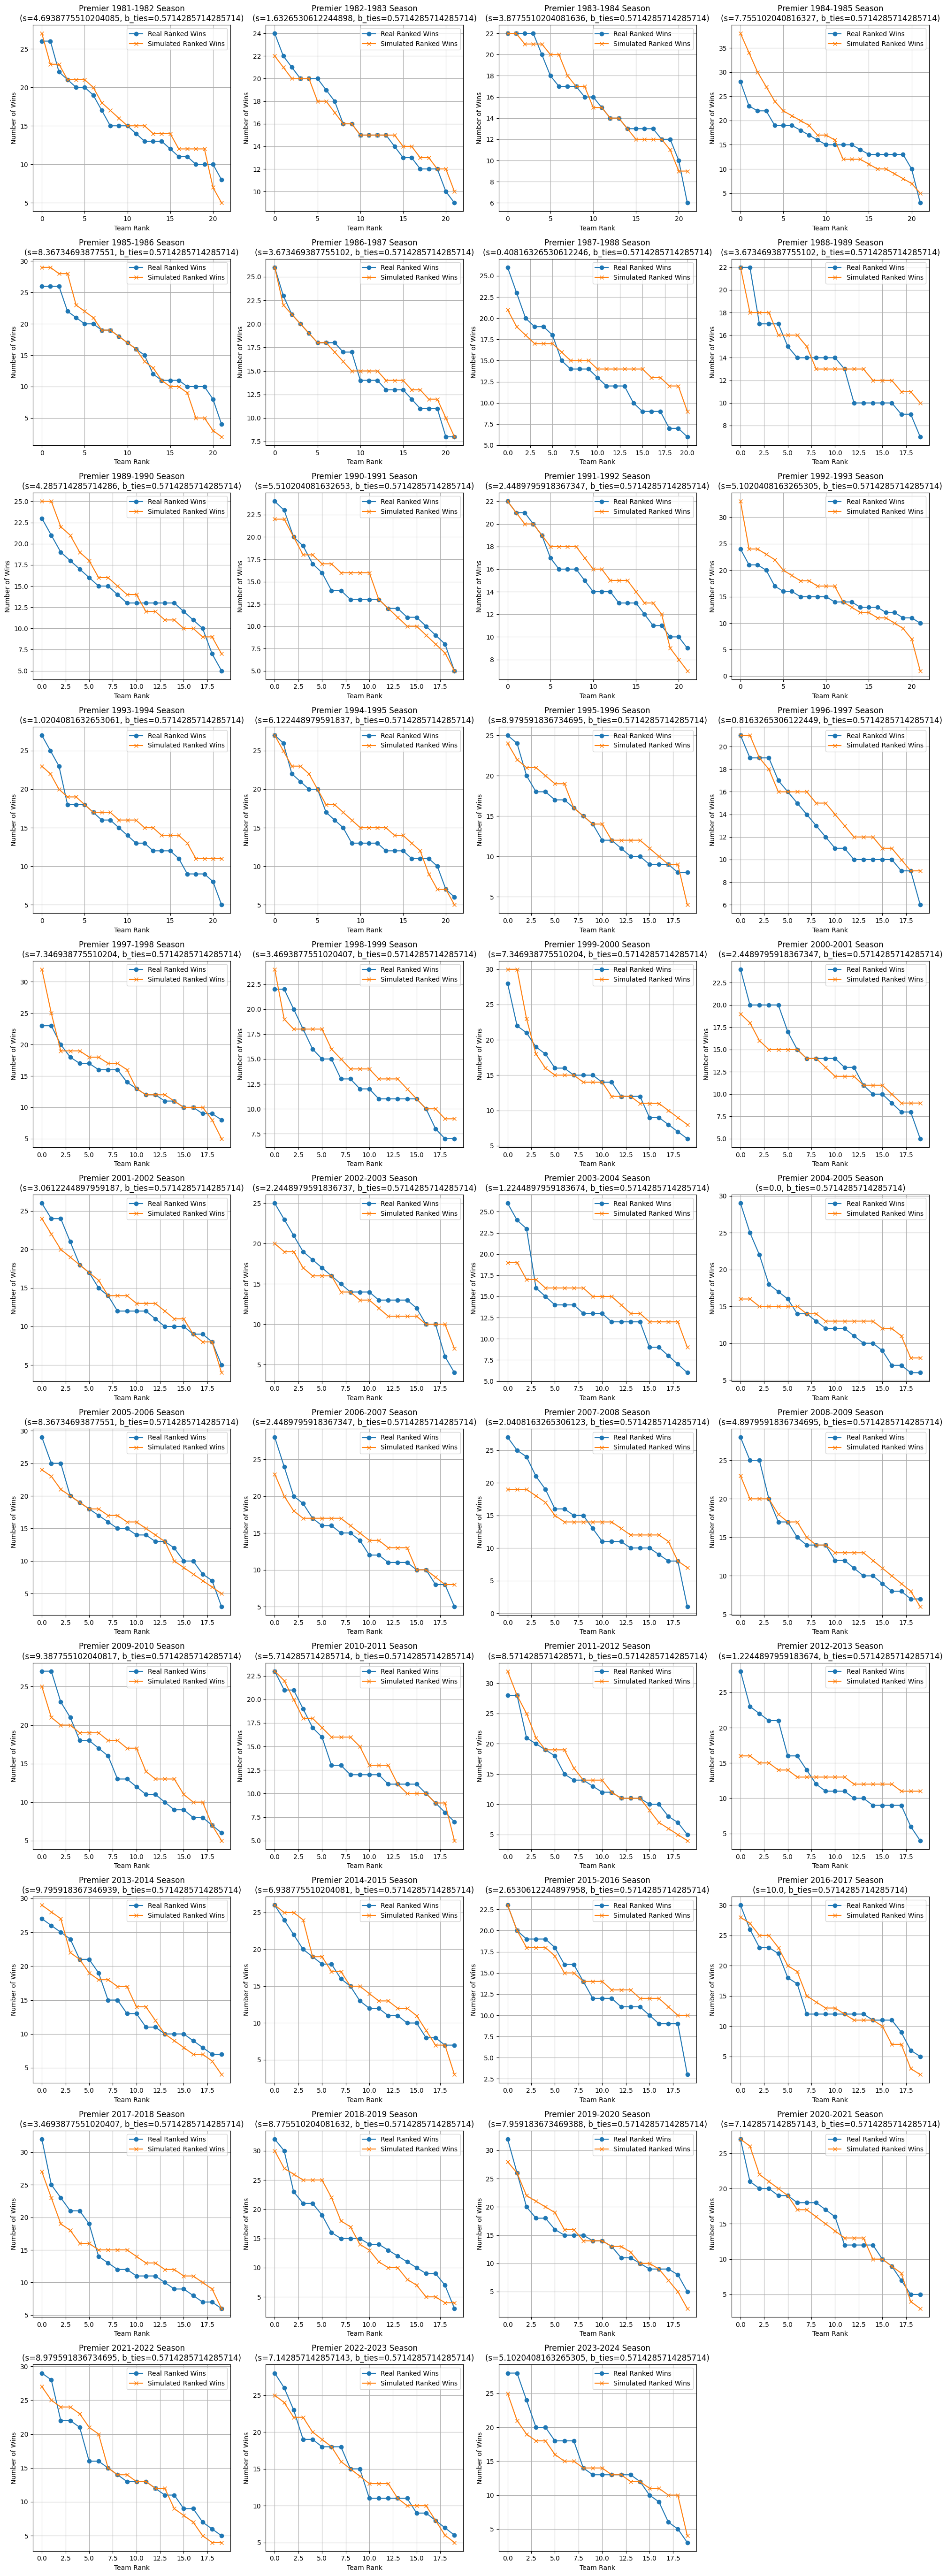

In [19]:
# Function to plot ranked wins
def plot_ranked_wins(ax, real_data, simulated_data, season, s, b):
    real_ranked_wins = sorted(real_data, reverse=True)
    simulated_ranked_wins = sorted(simulated_data, reverse=True)

    ax.plot(real_ranked_wins, label='Real Ranked Wins', marker='o')
    ax.plot(simulated_ranked_wins, label='Simulated Ranked Wins', marker='x')
    ax.set_title(f'Premier {season} Season\n(s={s}, b_ties={b})')
    ax.set_xlabel('Team Rank')
    ax.set_ylabel('Number of Wins')
    ax.legend()
    ax.grid(True)

# Number of plots per row
plots_per_row = 4

# Calculate number of rows needed
num_rows = (len(ties_df) + plots_per_row - 1) // plots_per_row

# Create subplots
fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 5))
axes = axes.flatten()  # Flatten the axes array for easy indexing

seasons_df = pd.DataFrame(seasons_data)

# Merge this DataFrame with the nba_data
merged_data = premier_data.merge(seasons_df, on='Season')

# Iterate through each season in df_s_mse and plot results
for index, row in ties_df.iterrows():
    season = row['Season']
    s = row['s']
    b = row['b']

    # Get the number of teams and games played per team for the season
    season_info = seasons_df[seasons_df['Season'] == season].iloc[0]
    num_teams = season_info['Number of Teams']
    games_per_team = season_info['Games Played per Team']

    # Simulate the league using the best parameters
    schedule = create_schedule(num_teams, int(games_per_team))
    simulation_result = simulate_league_with_ties(num_teams, int(games_per_team), s, b, schedule, seed=None)
    simulated_wins = [simulation_result[team]['wins'] for team in simulation_result]

    # Get the real wins for the season
    real_wins = merged_data.loc[merged_data['Season'] == season, 'Wins'].tolist()
    real_wins.sort(reverse=True)

    # Plot the ranked wins
    plot_ranked_wins(axes[index], real_wins, simulated_wins, season, s, b)

# Hide any unused subplots
for ax in axes[len(ties_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Calculate the winning percentage for each team in each season.
premier_data['Win Percentage'] = premier_data['Wins'] / (premier_data['Games Played'])

premier_data = premier_data[premier_data['Season'] >= '1981-1982']

# Group the historical_records by Season and calculate the standard deviation of the winning percentage.
std_win_pct_per_season = premier_data.groupby('Season')['Win Percentage'].std()

In [21]:
# Extract the seasons and best_s values from the DataFrame
seasons = ties_df['Season'].tolist()
best_s_ties = ties_df['s'].tolist()

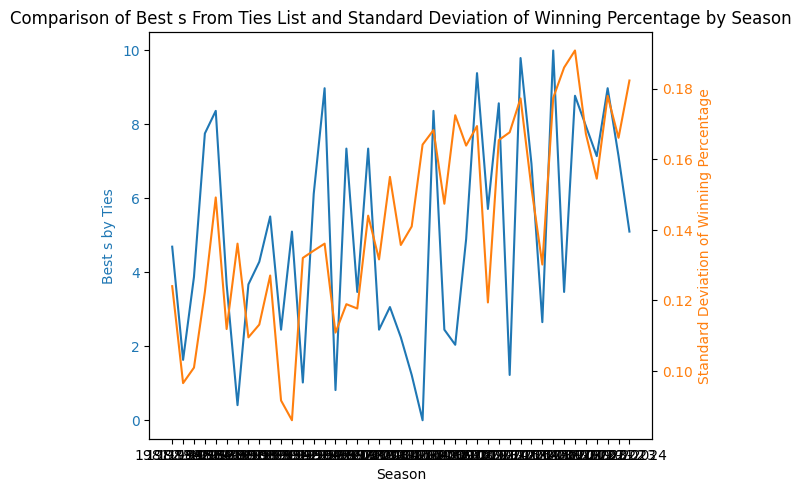

In [22]:
# Plotting the data on the same plot with two y-axes
fig, ax1 = plt.subplots()

ax1.set_xlabel('Season')
ax1.set_ylabel('Best s by Ties', color='tab:blue')
ax1.plot(seasons, best_s_ties, color='tab:blue', label='Best s for Each Season')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Standard Deviation of Winning Percentage', color='tab:orange')
ax2.plot(seasons, std_win_pct_per_season, color='tab:orange', label='Standard Deviation of Winning Percentage by Season')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Comparison of Best s From Ties List and Standard Deviation of Winning Percentage by Season')
plt.show()


In [23]:
#combine best_s_ties and std_win_pct_per_season

# Create a dictionary from best_s_ties, using seasons as keys
best_s_dict = dict(zip(seasons, best_s_ties))

# Create a new DataFrame from std_win_pct_per_season
std_win_pct_df_ties = std_win_pct_per_season.reset_index()
std_win_pct_df_ties.columns = ['Season', 'Std Win Pct']

# Add the 'Best s' column to the std_win_pct_df_ties DataFrame
std_win_pct_df_ties['Best s'] = std_win_pct_df_ties['Season'].map(best_s_dict)

# Print the combined DataFrame
print(std_win_pct_df_ties)


       Season  Std Win Pct     Best s
0   1981-1982     0.123990   4.693878
1   1982-1983     0.096499   1.632653
2   1983-1984     0.100894   3.877551
3   1984-1985     0.122357   7.755102
4   1985-1986     0.149144   8.367347
5   1986-1987     0.111836   3.673469
6   1987-1988     0.136048   0.408163
7   1988-1989     0.109473   3.673469
8   1989-1990     0.113100   4.285714
9   1990-1991     0.127005   5.510204
10  1991-1992     0.091566   2.448980
11  1992-1993     0.085975   5.102041
12  1993-1994     0.132000   1.020408
13  1994-1995     0.134066   6.122449
14  1995-1996     0.136046   8.979592
15  1996-1997     0.110821   0.816327
16  1997-1998     0.118882   7.346939
17  1998-1999     0.117649   3.469388
18  1999-2000     0.143986   7.346939
19  2000-2001     0.131572   2.448980
20  2001-2002     0.154976   3.061224
21  2002-2003     0.135670   2.244898
22  2003-2004     0.140915   1.224490
23  2004-2005     0.164120   0.000000
24  2005-2006     0.168238   8.367347
25  2006-200

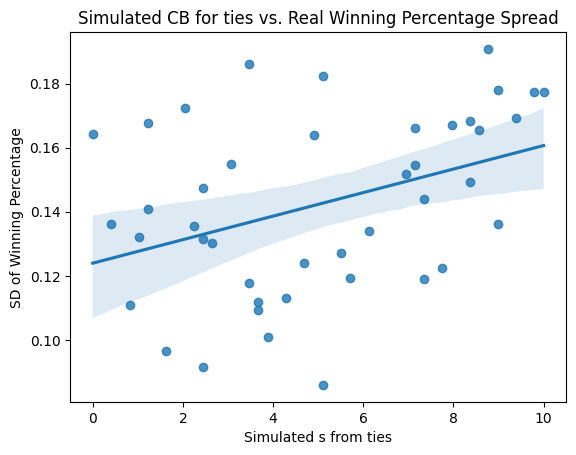

Slope: 0.0036706248755527405
Intercept: 0.12395987330307792
R-squared (R^2) 0.1524845669238389
P-value: 0.009629281177649378
Standard Error 0.0013514778662537857


In [24]:
# Create the scatter plot with a linear regression line using seaborn
sns.regplot(x='Best s', y='Std Win Pct', data = std_win_pct_df_ties)

# Labels and title
plt.xlabel('Simulated s from ties')
plt.ylabel('SD of Winning Percentage')
plt.title('Simulated CB for ties vs. Real Winning Percentage Spread')

# Show plot
plt.show()

# Calculate the slope using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(std_win_pct_df_ties['Best s'],std_win_pct_df_ties['Std Win Pct'])

# Print the slope
print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared (R^2)", r_value**2)
print("P-value:", p_value)
print("Standard Error", std_err)

# Using results fitted with wins

In [25]:
# Extract the seasons and best_s values from the DataFrame
seasons = wins_df['Season'].tolist()
best_s_wins = wins_df['s'].tolist()

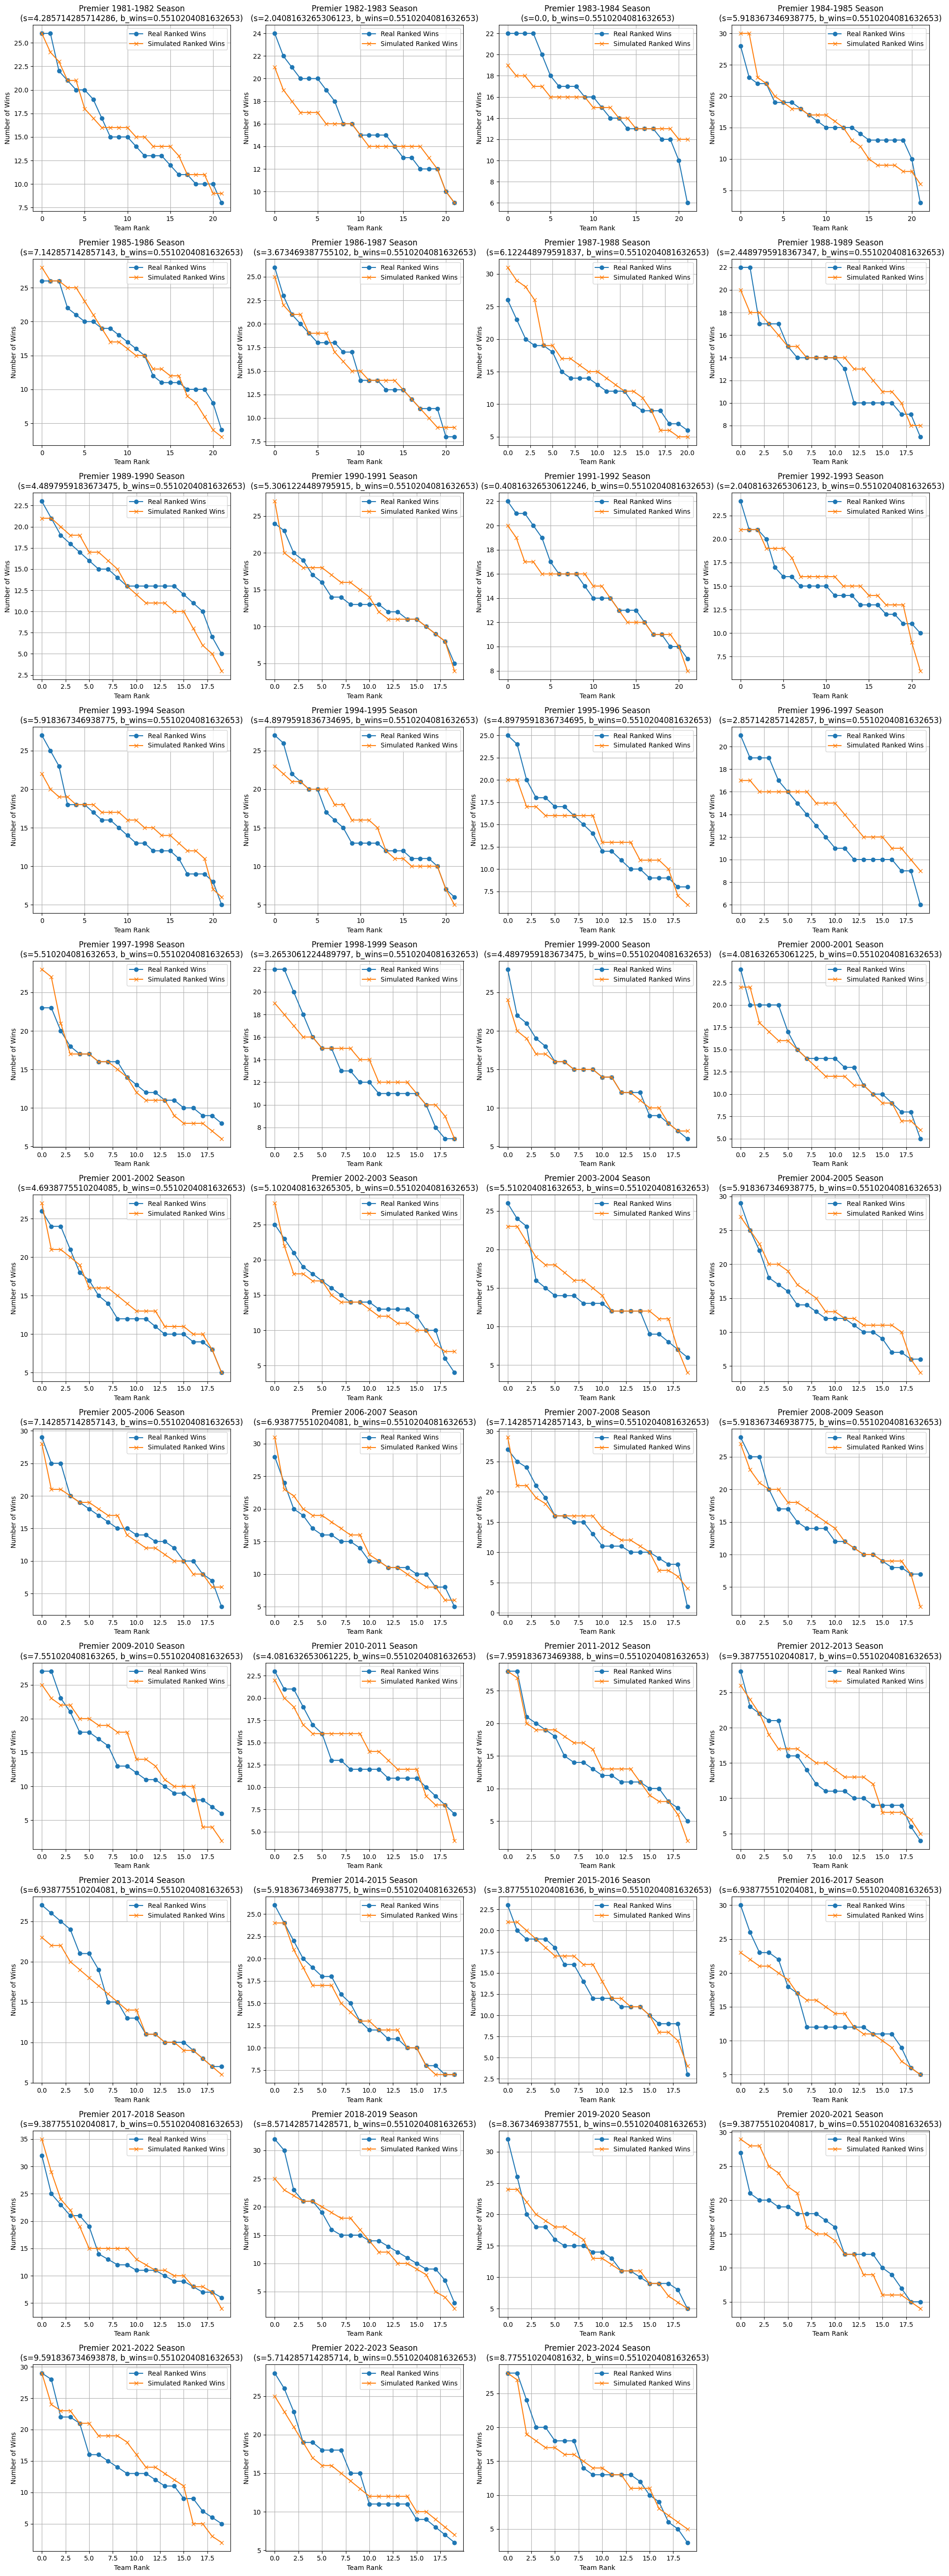

In [26]:
# Function to plot ranked wins
def plot_ranked_wins(ax, real_data, simulated_data, season, s, b):
    real_ranked_wins = sorted(real_data, reverse=True)
    simulated_ranked_wins = sorted(simulated_data, reverse=True)

    ax.plot(real_ranked_wins, label='Real Ranked Wins', marker='o')
    ax.plot(simulated_ranked_wins, label='Simulated Ranked Wins', marker='x')
    ax.set_title(f'Premier {season} Season\n(s={s}, b_wins={b})')
    ax.set_xlabel('Team Rank')
    ax.set_ylabel('Number of Wins')
    ax.legend()
    ax.grid(True)

# Number of plots per row
plots_per_row = 4

# Calculate number of rows needed
num_rows = (len(ties_df) + plots_per_row - 1) // plots_per_row

# Create subplots
fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 5))
axes = axes.flatten()  # Flatten the axes array for easy indexing

seasons_df = pd.DataFrame(seasons_data)

# Merge this DataFrame with the nba_data
merged_data = premier_data.merge(seasons_df, on='Season')

# Iterate through each season in df_s_mse and plot results
for index, row in wins_df.iterrows():
    season = row['Season']
    s = row['s']
    b = row['b']

    # Get the number of teams and games played per team for the season
    season_info = seasons_df[seasons_df['Season'] == season].iloc[0]
    num_teams = season_info['Number of Teams']
    games_per_team = season_info['Games Played per Team']

    # Simulate the league using the best parameters
    schedule = create_schedule(num_teams, int(games_per_team))
    simulation_result = simulate_league_with_ties(num_teams, int(games_per_team), s, b, schedule, seed=None)
    simulated_wins = [simulation_result[team]['wins'] for team in simulation_result]

    # Get the real wins for the season
    real_wins = merged_data.loc[merged_data['Season'] == season, 'Wins'].tolist()
    real_wins.sort(reverse=True)

    # Plot the ranked wins
    plot_ranked_wins(axes[index], real_wins, simulated_wins, season, s, b)

# Hide any unused subplots
for ax in axes[len(ties_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

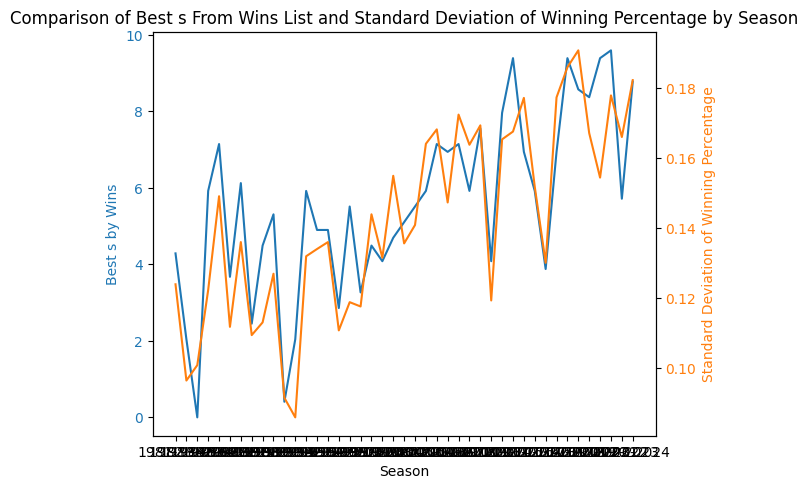

In [27]:
# Plotting the data on the same plot with two y-axes
fig, ax1 = plt.subplots()

ax1.set_xlabel('Season')
ax1.set_ylabel('Best s by Wins', color='tab:blue')
ax1.plot(seasons, best_s_wins, color='tab:blue', label='Best s for Each Season')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Standard Deviation of Winning Percentage', color='tab:orange')
ax2.plot(seasons, std_win_pct_per_season, color='tab:orange', label='Standard Deviation of Winning Percentage by Season')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Comparison of Best s From Wins List and Standard Deviation of Winning Percentage by Season')
plt.show()

In [28]:
#combine best_s_ties and std_win_pct_per_season

# Create a dictionary from best_s_ties, using seasons as keys
best_s_dict = dict(zip(seasons, best_s_wins))

# Create a new DataFrame from std_win_pct_per_season
std_win_pct_df_wins = std_win_pct_per_season.reset_index()
std_win_pct_df_wins.columns = ['Season', 'Std Win Pct']

# Add the 'Best s' column to the std_win_pct_df_ties DataFrame
std_win_pct_df_wins['Best s'] = std_win_pct_df_wins['Season'].map(best_s_dict)

# Print the combined DataFrame
print(std_win_pct_df_wins)

       Season  Std Win Pct    Best s
0   1981-1982     0.123990  4.285714
1   1982-1983     0.096499  2.040816
2   1983-1984     0.100894  0.000000
3   1984-1985     0.122357  5.918367
4   1985-1986     0.149144  7.142857
5   1986-1987     0.111836  3.673469
6   1987-1988     0.136048  6.122449
7   1988-1989     0.109473  2.448980
8   1989-1990     0.113100  4.489796
9   1990-1991     0.127005  5.306122
10  1991-1992     0.091566  0.408163
11  1992-1993     0.085975  2.040816
12  1993-1994     0.132000  5.918367
13  1994-1995     0.134066  4.897959
14  1995-1996     0.136046  4.897959
15  1996-1997     0.110821  2.857143
16  1997-1998     0.118882  5.510204
17  1998-1999     0.117649  3.265306
18  1999-2000     0.143986  4.489796
19  2000-2001     0.131572  4.081633
20  2001-2002     0.154976  4.693878
21  2002-2003     0.135670  5.102041
22  2003-2004     0.140915  5.510204
23  2004-2005     0.164120  5.918367
24  2005-2006     0.168238  7.142857
25  2006-2007     0.147363  6.938776
2

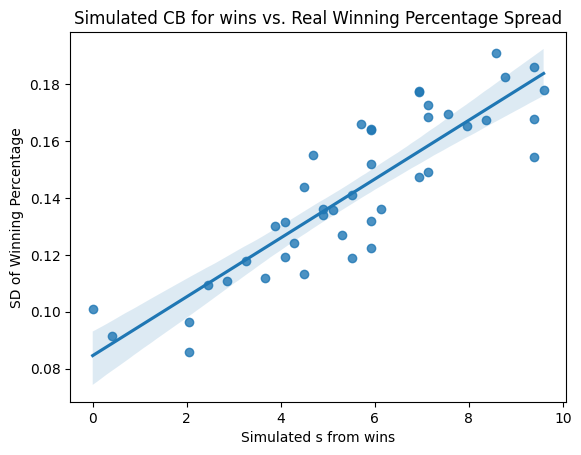

Slope: 0.010332634622221238
Intercept: 0.08459117621533
R-squared (R^2) 0.768490483420582
P-value: 1.320531367943273e-14
Standard Error 0.000885695261390614


In [29]:
# Create the scatter plot with a linear regression line using seaborn
sns.regplot(x='Best s', y='Std Win Pct', data = std_win_pct_df_wins)

# Labels and title
plt.xlabel('Simulated s from wins')
plt.ylabel('SD of Winning Percentage')
plt.title('Simulated CB for wins vs. Real Winning Percentage Spread')

# Show plot
plt.show()

# Calculate the slope using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(std_win_pct_df_wins['Best s'],std_win_pct_df_wins['Std Win Pct'])

# Print the slope
print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared (R^2)", r_value**2)
print("P-value:", p_value)
print("Standard Error", std_err)

In [30]:
score_difference_adjusted = pd.read_excel('/content/premier_scorediff_dominance_adjusted.xlsx')

In [31]:
print(score_difference_adjusted)

       Season  Score Difference  Dominance Index
0   1946-1947          0.556277        10.434783
1   1947-1948          0.508658        17.647059
2   1948-1949          0.426407        15.447154
3   1949-1950          0.573593        16.535433
4   1950-1951          0.400433        12.977099
..        ...               ...              ...
72  2018-2019          0.884211        26.054591
73  2019-2020          0.821053        33.169533
74  2020-2021          0.694737        33.819951
75  2021-2022          0.897368        27.710843
76  2022-2023          0.763158        31.264916

[77 rows x 3 columns]


In [32]:
#get the score difference df for 1980 season onward

score_difference_1980_onward = score_difference_adjusted[score_difference_adjusted['Season'] >= '1981-1982']
print(score_difference_1980_onward)


       Season  Score Difference  Dominance Index
35  1981-1982          0.404762        23.529412
36  1982-1983          0.428571        21.621622
37  1983-1984          0.545455        17.870722
38  1984-1985          0.601732        29.213483
39  1985-1986          0.675325        24.354244
40  1986-1987          0.474026        28.000000
41  1987-1988          0.630952        26.881720
42  1988-1989          0.536842        17.667845
43  1989-1990          0.410526        26.132404
44  1990-1991          0.639474        20.274914
45  1991-1992          0.406926        22.372881
46  1992-1993          0.307359        15.050167
47  1993-1994          0.660173        21.452145
48  1994-1995          0.599567        23.452769
49  1995-1996          0.668421        27.009646
50  1996-1997          0.489474        30.793651
51  1997-1998          0.671053        29.153605
52  1998-1999          0.623684        23.219814
53  1999-2000          0.673684        32.721713
54  2000-2001       

In [33]:
score_difference = score_difference_1980_onward['Score Difference']

# Ties' s with score difference

In [34]:
# let best_s_wins not include 2023-2024 season

# Filter out the 2023-2024 season from wins_df
ties_df_less = ties_df[ties_df['Season'] != '2023-2024']

# Extract the seasons and best_s values from the filtered DataFrame
seasons = ties_df_less['Season'].tolist()
best_s_ties_less = ties_df_less['s'].tolist()


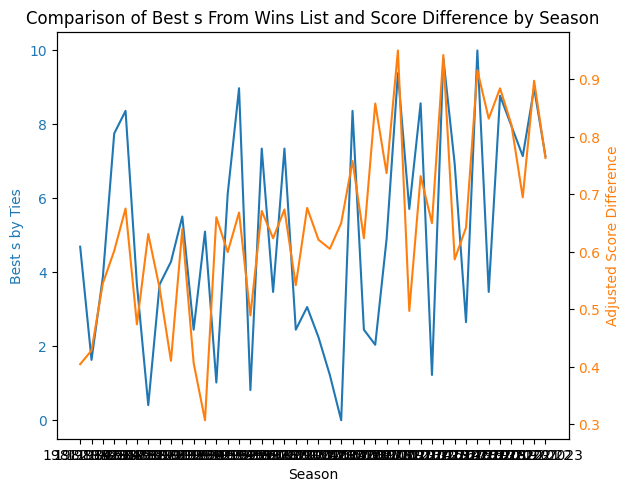

In [35]:
# Plotting the data on the same plot with two y-axes
fig, ax1 = plt.subplots()

ax1.set_xlabel('Season')
ax1.set_ylabel('Best s by Ties', color='tab:blue')
ax1.plot(seasons, best_s_ties_less, color='tab:blue', label='Best s for Each Season')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Adjusted Score Difference', color='tab:orange')
ax2.plot(seasons, score_difference, color='tab:orange', label='Score Difference by Season')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Comparison of Best s From Wins List and Score Difference by Season')
plt.show()

# Wins' S with Score Difference

In [36]:
# Filter out the 2023-2024 season from wins_df
wins_df_less = wins_df[ties_df['Season'] != '2023-2024']

best_s_wins_less = wins_df_less['s'].tolist()

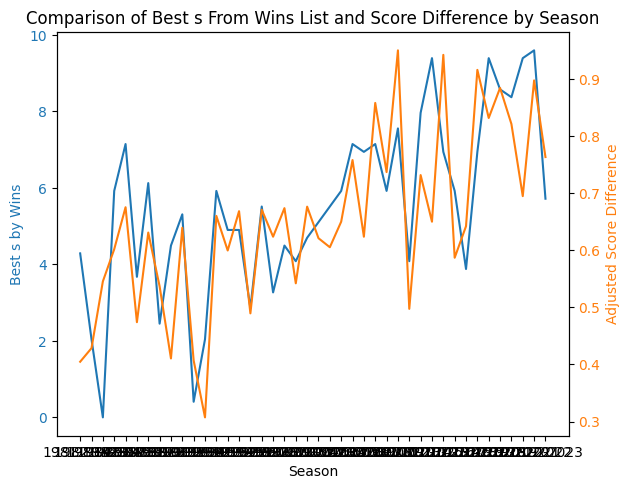

In [37]:
# Plotting the data on the same plot with two y-axes
fig, ax1 = plt.subplots()

ax1.set_xlabel('Season')
ax1.set_ylabel('Best s by Wins', color='tab:blue')
ax1.plot(seasons, best_s_wins_less, color='tab:blue', label='Best s for Each Season')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Adjusted Score Difference', color='tab:orange')
ax2.plot(seasons, score_difference, color='tab:orange', label='Score Difference by Season')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Comparison of Best s From Wins List and Score Difference by Season')
plt.show()